In [9]:
import pandas as pd

df = pd.read_csv('../data/preprocessed/final_master_training_set.csv')

In [10]:


df = df[['text_features', 'classification']]
print(df.head())

                                       text_features   classification
0  Adaptation Platform Canada (2012) Strategic pl...  adaptation only
1  Canadian Agricultural Adaptation Program Canad...  adaptation only
2  Climate Change Adaptation Act Japan (2015) Pol...  adaptation only
3  Climate Ready States and Cities Initiative Uni...  adaptation only
4  Climate Ready Water Utilities (CRWU) United St...  adaptation only


In [11]:
#When creating a classifier we need to split our data into 
#training and test sets
#we train on a portion of the data and test on another portion of the data
#important that these samples are performed randomly 
train = df.sample(frac = 0.8)
test = df.drop(train.index)
print(train.shape)
print(test.shape)

(5455, 2)
(1364, 2)


In [12]:
#sklearn is a very large library
#therefore we typically import only the functions we are actually going to use
from sklearn.feature_extraction.text import CountVectorizer

#A 'vectorizer' turns text data into a numeric matrix
#which can then be used by the model
vectorizer = CountVectorizer()
train_vectors = vectorizer.fit_transform(train['text_features'])
test_vectors = vectorizer.transform(test['text_features'])
#nb diff between transform and fit transform

In [13]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
clf.fit(train_vectors, train['classification'])
test['pred'] = clf.predict(test_vectors)

In [14]:
test.head()

,text_features,classification,pred
0,Adaptation Platform Canada (2012) Strategic pl...,adaptation only,adaptation only
5,Environmental Quality Incentives Program (EQIP...,adaptation only,mitigation only
6,Executive Order 13653: Preparing the United St...,adaptation only,adaptation only
11,National Climate Resilience and Adaptation Str...,adaptation only,adaptation only
19,Public Transportation Emergency Relief Program...,adaptation only,mitigation only


In [15]:
#definitions can be found here: 
#https://medium.com/@shrutisaxena0617/precision-vs-recall-386cf9f89488
from sklearn import metrics
print(metrics.accuracy_score(test['classification'], test['pred']))
print(metrics.precision_score(test['classification'], test['pred'], average='macro'))
print(metrics.recall_score(test['classification'], test['pred'], average='macro'))

0.9178885630498533
0.778525980911983
0.6842299476708079


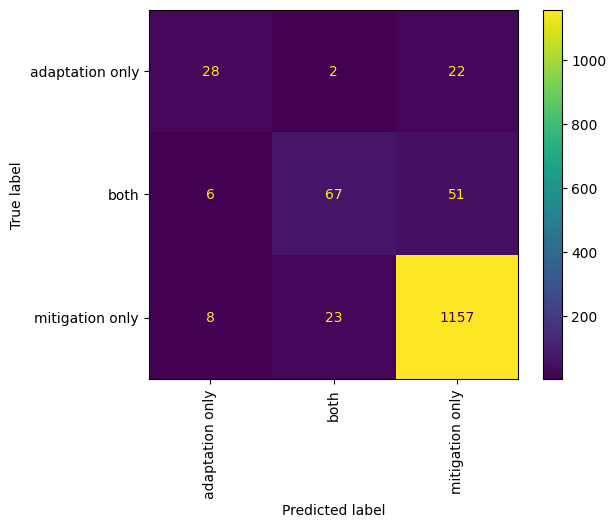

In [16]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test['classification'], test['pred'], labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=clf.classes_)
disp.plot(xticks_rotation = 'vertical')
plt.show()